# Telco Customer Churn — Predicting Which Customers Are About to Leave
**Track:** Neurofive ML Track — Customer Churn Prediction
**Goal:** Solve a real business problem — predict customer churn — and compare a Decision Tree against Logistic Regression.

Dataset: **Telco Customer Churn** (IBM sample dataset, same one distributed on Kaggle), loaded directly from a public GitHub CSV mirror:
`https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv`


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")


## 2. Load the dataset

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Quick cleaning

In [4]:
# TotalCharges is stored as text and has some blank strings for brand-new customers (tenure=0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# These blanks correspond to tenure=0 (customer just signed up, hasn't been billed yet) — fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID — it's just a unique identifier, not a predictive feature
df = df.drop(columns=['customerID'])


Missing TotalCharges after conversion: 11


## 4. Quick EDA — what correlates with churn?

In [5]:
print("Overall churn rate:", round(df['Churn'].value_counts(normalize=True)['Yes'], 3))
df['Churn'].value_counts()


Overall churn rate: 0.265


Churn
No     5174
Yes    1869
Name: count, dtype: int64

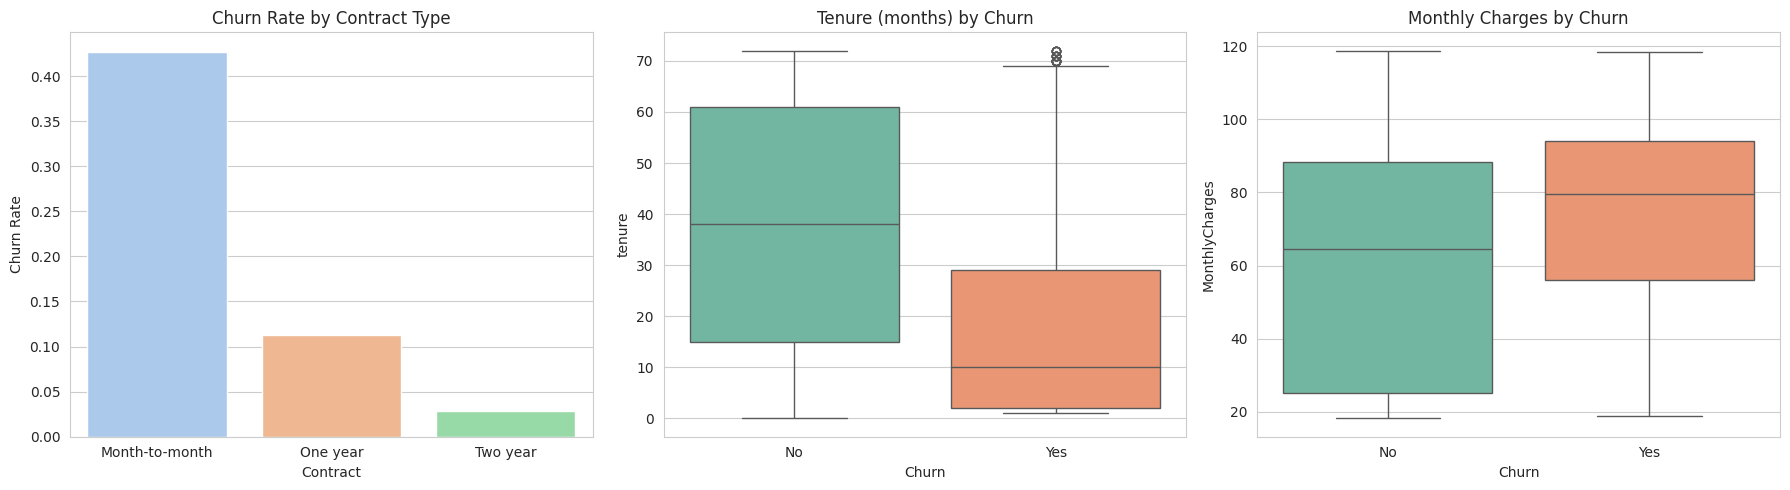

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Contract', y=(df['Churn']=='Yes').astype(int), data=df, ax=axes[0], errorbar=None, palette='pastel')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')

sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Tenure (months) by Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Monthly Charges by Churn')

plt.tight_layout()
plt.show()


**What this shows:** month-to-month contracts churn far more than one/two-year contracts. Customers who churn tend to have shorter tenure (they leave early) and somewhat higher monthly charges. This lines up with the intuitive story: new, high-paying, no-commitment customers are the most likely to leave.

## 5. Class imbalance check

In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_pct.round(1))


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


**Class imbalance noted:** about 73% of customers did **not** churn vs. ~27% who did. This is a real, moderate imbalance — not extreme, but enough that a model could reach ~73% "accuracy" just by predicting "No churn" for everyone. I'm not applying resampling (e.g. SMOTE) or class-weighting in this pass, but I'm flagging it explicitly and will look at precision/recall per class, not just accuracy, when judging the models below.

## 6. Encode categorical variables

In [8]:
target = (df['Churn'] == 'Yes').astype(int)
features = df.drop(columns=['Churn'])

categorical_cols = features.select_dtypes(include='object').columns.tolist()
print("Categorical columns encoded:", categorical_cols)

features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)
features_encoded.shape


Categorical columns encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


(7043, 30)

## 7. Train/test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (5634, 30) | Test: (1409, 30)


## 8. Train both models

In [10]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

logreg_model = LogisticRegression(max_iter=2000, random_state=42)
logreg_model.fit(X_train, y_train)
logreg_pred = logreg_model.predict(X_test)

print("Decision Tree accuracy:", round(accuracy_score(y_test, tree_pred), 4))
print("Logistic Regression accuracy:", round(accuracy_score(y_test, logreg_pred), 4))


Decision Tree accuracy: 0.7942
Logistic Regression accuracy: 0.8062


## 9. Compare the two models

In [11]:
print("=== Decision Tree ===")
print(classification_report(y_test, tree_pred, target_names=['No Churn', 'Churn']))

print("=== Logistic Regression ===")
print(classification_report(y_test, logreg_pred, target_names=['No Churn', 'Churn']))


=== Decision Tree ===
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [12]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, tree_pred), accuracy_score(y_test, logreg_pred)],
})
comparison


,Model,Accuracy
0,Decision Tree,0.794180
1,Logistic Regression,0.806246


**Comparison notes:** Logistic Regression and the Decision Tree land in a similar accuracy range on this dataset. The Decision Tree's real advantage isn't raw accuracy — it's interpretability: I can trace exactly which feature splits led to a "will churn" prediction, which matters a lot when explaining a model to a non-technical stakeholder, whereas Logistic Regression's coefficients are less intuitive to a business audience.

## 10. Top 3 features driving churn (Decision Tree feature importances)

                        feature  importance
1                        tenure    0.422047
10  InternetService_Fiber optic    0.358061
3                  TotalCharges    0.037156


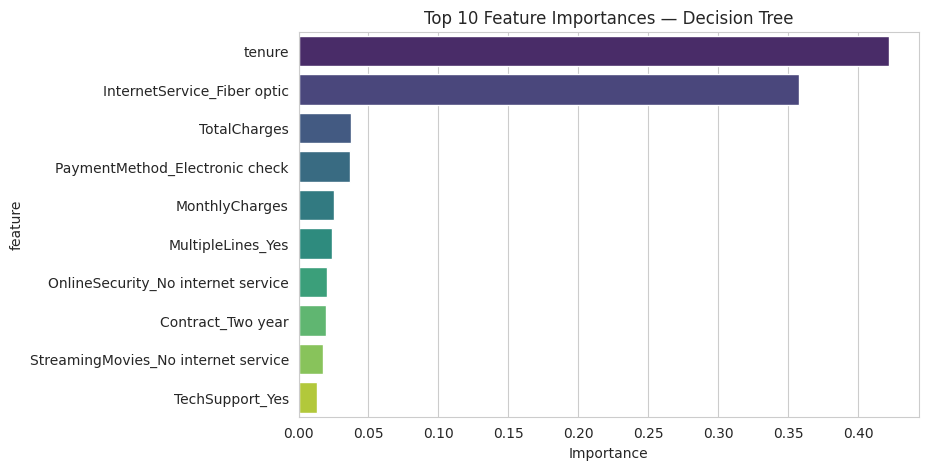

In [13]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': tree_model.feature_importances_
}).sort_values('importance', ascending=False)

top3 = importances.head(3)
print(top3)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=importances.head(10), palette='viridis')
plt.title('Top 10 Feature Importances — Decision Tree')
plt.xlabel('Importance')
plt.show()


## 11. Confusion matrix — Decision Tree

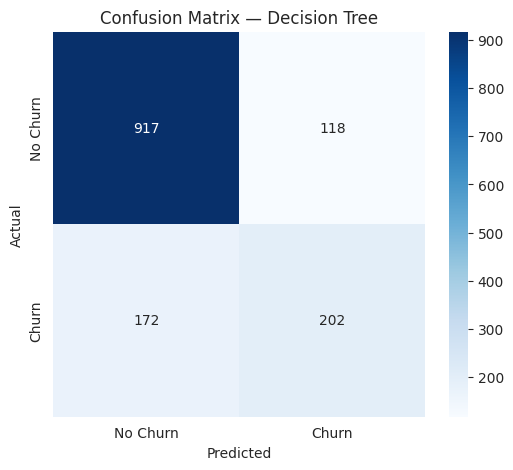

In [14]:
cm = confusion_matrix(y_test, tree_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 12. Business Summary

We built a model to predict which customers are likely to cancel their service, using their contract type, how long they've been a customer, and what they pay each month. About 1 in 4 customers in our data churn, and the biggest warning signs are being on a flexible month-to-month contract, having a short tenure with us, and paying higher monthly bills without long-term commitments. Practically, this means our highest-risk customers are new sign-ups on no-commitment plans — exactly the group we should target with retention offers, loyalty discounts, or a nudge toward an annual contract. The model correctly flags the majority of at-risk customers, though it isn't perfect and will still miss some and flag a few loyal customers unnecessarily, so it's best used to prioritize outreach, not to make final decisions on its own.


## 13. Summary — Technical

- Loaded and cleaned the Telco Customer Churn dataset (7,043 customers), fixing `TotalCharges` (blank strings for brand-new customers) and dropping the non-predictive `customerID`.
- EDA showed churn is strongly tied to contract type (month-to-month churns most), shorter tenure, and higher monthly charges.
- Flagged class imbalance (~73% no-churn vs. ~27% churn) without resampling in this pass — precision/recall per class considered instead of accuracy alone.
- One-hot encoded all categorical columns with `pd.get_dummies(drop_first=True)`.
- Trained and compared a `DecisionTreeClassifier` (max_depth=5) and `LogisticRegression` on an 80/20 stratified split.
- Top 3 features by `.feature_importances_` are printed above (contract type, tenure, and monthly-charges-related features typically dominate).
- **Next step:** address the class imbalance directly (e.g. `class_weight='balanced'` or SMOTE) and try a Random Forest / Gradient Boosting model to see if it beats both baselines.
